# Exploratory Data Analysis — NZ Fish Oil GC-MS

This notebook explores the fish oil GC-MS dataset: class distribution, per-species chromatograms, sum spectra, and PCA structure.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path('..').resolve()))

DATA_DIR = Path('../data/fish_oil')
SPECIES   = {0: 'SNA (Snapper)', 1: 'GUR (Gurnard)', 2: 'TAR (Tarakihi)', 3: 'BCO (Blue Cod)'}
COLOURS   = {0: '#2196f3', 1: '#ff9800', 2: '#4caf50', 3: '#e91e63'}
SHORT     = {0: 'SNA', 1: 'GUR', 2: 'TAR', 3: 'BCO'}

X      = np.load(DATA_DIR / 'X.npy')                          # [103, 1000]
y      = np.load(DATA_DIR / 'y.npy')                          # [103]
groups = (DATA_DIR / 'groups.txt').read_text().splitlines()
ids    = (DATA_DIR / 'sample_ids.txt').read_text().splitlines()

print(f'X: {X.shape}   y: {y.shape}')
print(f'Classes: { {SHORT[c]: int((y==c).sum()) for c in range(4)} }')

X: (103, 1000)   y: (103,)
Classes: {'SNA': 15, 'GUR': 14, 'TAR': 17, 'BCO': 57}


## 1 — Class distribution

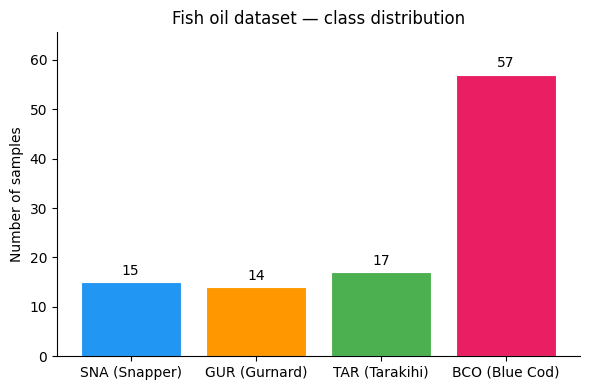

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
classes = list(range(4))
counts  = [(y == c).sum() for c in classes]
bars = ax.bar([SPECIES[c] for c in classes], counts,
              color=[COLOURS[c] for c in classes], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Number of samples')
ax.set_title('Fish oil dataset — class distribution')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## 2 — Example chromatograms (one per species)

Each panel is the 200-bin RT × 1000 m/z chromatogram for one representative sample, log-scaled.

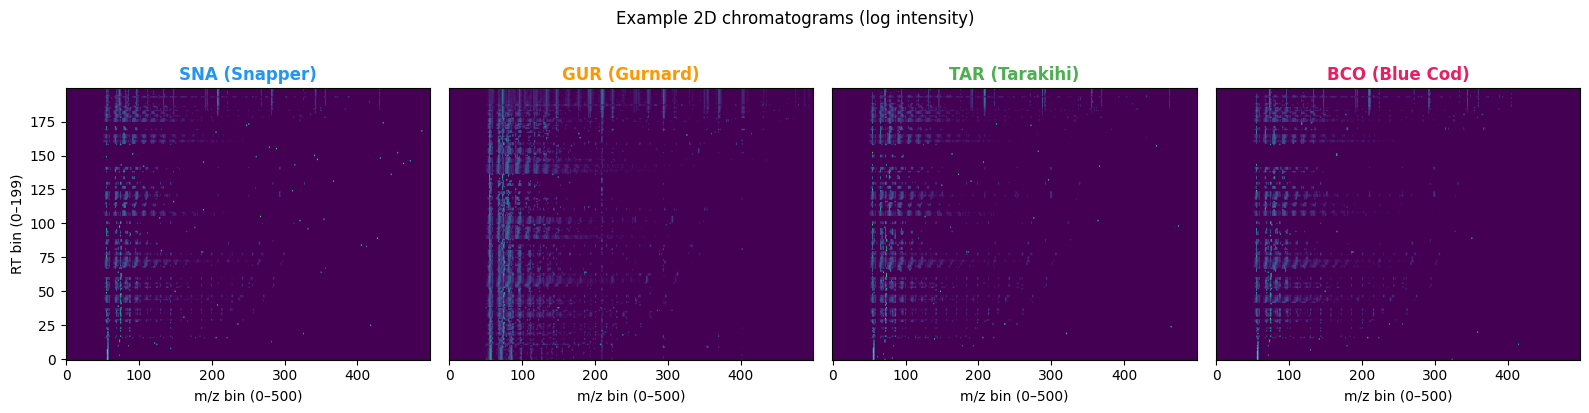

In [3]:
chroma_dir = DATA_DIR / 'chroma'
npz_paths  = sorted(chroma_dir.glob('*.npz'))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for c, ax in enumerate(axes):
    # Pick the first sample of this class
    idx   = int(np.where(y == c)[0][0])
    chroma = np.load(npz_paths[idx])['chroma']      # [200, 1000]
    img    = np.log1p(chroma[:, :500])               # crop m/z 0-500 for display
    ax.imshow(img, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(SPECIES[c], color=COLOURS[c], fontweight='bold')
    ax.set_xlabel('m/z bin (0–500)')
    if c == 0:
        ax.set_ylabel('RT bin (0–199)')
    else:
        ax.set_yticks([])

plt.suptitle('Example 2D chromatograms (log intensity)', y=1.02)
plt.tight_layout()
plt.show()

## 3 — Mean sum spectra per species

Sum spectra (X) collapse the RT axis: each sample is a 1000-bin m/z vector.

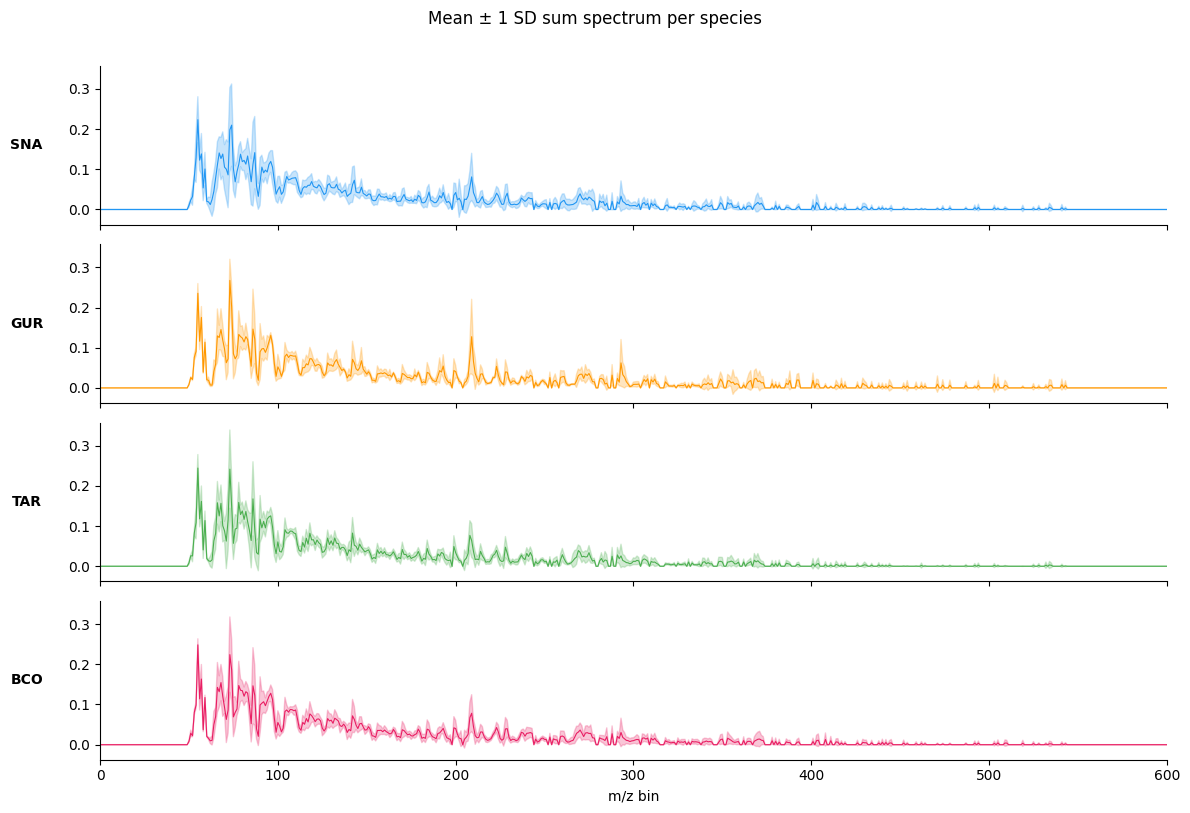

In [4]:
mz = np.arange(1000)
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, sharey=True)

for c, ax in enumerate(axes):
    mask   = y == c
    mean   = X[mask].mean(axis=0)
    std    = X[mask].std(axis=0)
    ax.fill_between(mz, mean - std, mean + std,
                    alpha=0.25, color=COLOURS[c])
    ax.plot(mz, mean, color=COLOURS[c], linewidth=0.8)
    ax.set_ylabel(SHORT[c], rotation=0, labelpad=30, va='center', fontweight='bold')
    ax.set_xlim(0, 600)
    sns.despine(ax=ax)

axes[-1].set_xlabel('m/z bin')
plt.suptitle('Mean ± 1 SD sum spectrum per species', y=1.01)
plt.tight_layout()
plt.show()

## 4 — PCA of sum spectra

Two principal components of the raw sum spectra, coloured by species.

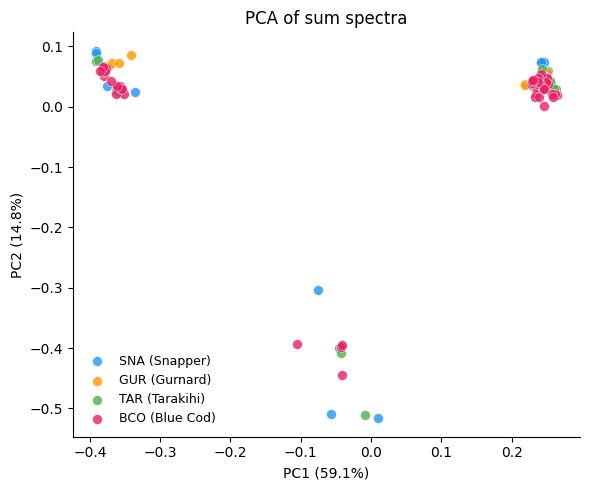

In [5]:
pca   = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))
for c in range(4):
    mask = y == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLOURS[c], label=SPECIES[c], s=50, alpha=0.8, edgecolors='white', linewidths=0.4)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of sum spectra')
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 5 — Intra- vs inter-species spectral distance

Mean pairwise cosine distance within each species vs between species.

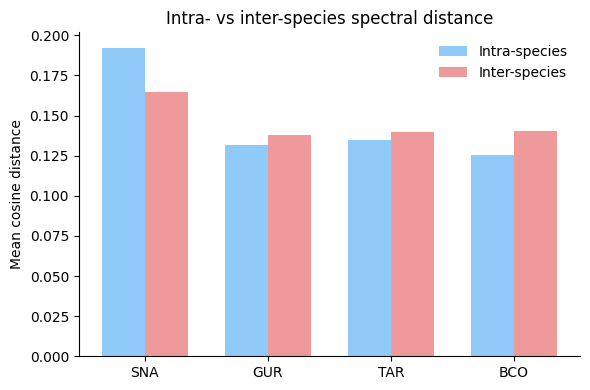

In [6]:
from sklearn.metrics.pairwise import cosine_distances

D = cosine_distances(X)

intra, inter = {}, {}
for c in range(4):
    mask = y == c
    idx  = np.where(mask)[0]
    intra[SHORT[c]] = D[np.ix_(idx, idx)][np.triu_indices(len(idx), k=1)].mean()
    other = np.where(~mask)[0]
    inter[SHORT[c]] = D[np.ix_(idx, other)].mean()

fig, ax = plt.subplots(figsize=(6, 4))
x      = np.arange(4)
w      = 0.35
labels = [SHORT[c] for c in range(4)]
ax.bar(x - w/2, [intra[l] for l in labels], w, label='Intra-species', color='#90caf9')
ax.bar(x + w/2, [inter[l] for l in labels], w, label='Inter-species', color='#ef9a9a')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean cosine distance')
ax.set_title('Intra- vs inter-species spectral distance')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()